# Topic Modeling — Skenario S3: Perbandingan 5 Embedding Model

**Tujuan:** Mengevaluasi pengaruh pilihan *sentence embedding model* terhadap kualitas topik (Coherence C_v) pada BERTopic untuk korpus berita Indonesia.

**5 Embedding Model yang dibandingkan** (fokus model khusus Bahasa Indonesia + 1 multilingual sebagai baseline):

| Key | Model | Dim | Karakteristik |
|---|---|---|---|
| `mpnet-multi`  | `paraphrase-multilingual-mpnet-base-v2` | 768 | **Baseline multilingual** — kuat untuk banyak bahasa |
| `indo-sbert`   | `firqaaa/indo-sentence-bert-base` | 768 | IndoBERT + paraphrase training (Indonesia) |
| `indo-sbert-l` | `denaya/indoSBERT-large` | 1024 | IndoBERT *large* + STSb-mt-id (Indonesia) |
| `indo-e5-base` | `LazarusNLP/all-indo-e5-base-v4` | 768 | XLM-R + E5 distillation (Indonesia) |
| `indo-sbert-n` | `naufalihsan/indonesian-sbert-large` | 1024 | IndoBERT *large* + STSb (Indonesia, alternatif) |

**Hipotesis:** Model yang di-train khusus pada teks Bahasa Indonesia *seharusnya* menghasilkan coherence lebih tinggi dibanding model multilingual generik, karena representasi semantiknya lebih cocok dengan korpus berita Indonesia.

**Kontrol eksperimen:** UMAP, HDBSCAN, dan jumlah topik target (`K_BERT_TARGET`) **disamakan** di semua model — hanya embedding-nya yang berbeda. Dengan begitu, perbedaan coherence murni mencerminkan kualitas representasi semantik tiap model.

### Referensi
- Reimers & Gurevych (2020): *Making Monolingual Sentence Embeddings Multilingual using Knowledge Distillation*
- Feng et al. (2022): *Language-agnostic BERT Sentence Embedding (LaBSE)*
- Grootendorst (2022): *BERTopic: Neural topic modeling with a class-based TF-IDF procedure*
- Wilie et al. (2020): *IndoNLU: Benchmark and Resources for Evaluating Indonesian Natural Language Understanding*

## 1. Setup

In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan gensim wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12

In [2]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Coherence (pakai gensim untuk fair-comparison dengan S1)
import gensim.corpora as corpora
from gensim.models import CoherenceModel

# BERTopic stack
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from wordcloud import WordCloud

2026-06-12 14:36:55.751444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781275015.947974      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781275016.005595      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781275016.464131      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781275016.464175      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781275016.464177      22 computation_placer.cc:177] computation placer alr

In [3]:
DATA_DIR   = '/kaggle/input/datasets/mikhaelsaputra/fptext'                       # lokasi corpus_*.json
OUTPUT_DIR = '/kaggle/working'                # cache embedding & hasil komparasi
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 5 embedding model — fokus pada model khusus Bahasa Indonesia
# (1 multilingual sebagai baseline pembanding, 4 Indonesia-specific)
EMBEDDING_MODELS = {
    'mpnet-multi':  'paraphrase-multilingual-mpnet-base-v2',  # 768d — baseline multilingual terkuat
    'indo-sbert':   'firqaaa/indo-sentence-bert-base',        # 768d — IndoBERT + paraphrase
    'indo-sbert-l': 'denaya/indoSBERT-large',                 # 1024d — IndoBERT large + STSb-mt-id
    'indo-e5-base': 'intfloat/multilingual-e5-base',         # 768d — XLM-R base + E5 distillation
    'indo-sbert-n': 'naufalihsan/indonesian-sbert-large',     # 1024d — IndoBERT large + STSb (alternatif)
}

# Hyperparameter eksperimen — SAMA untuk semua model
K_BERT_TARGET = 15        # target jumlah topik final (untuk fairness)
MIN_CLUSTER   = 50        # HDBSCAN min_cluster_size
UMAP_NEIGH    = 15        # UMAP n_neighbors
UMAP_DIM      = 5         # UMAP n_components
BATCH_SIZE    = 64        # encoder batch size
RANDOM_SEED   = 42
PALETTE       = 'tab20'

print(f'Jumlah model embedding : {len(EMBEDDING_MODELS)}')
print(f'Target topik (K)       : {K_BERT_TARGET}')
print(f'Output dir             : {os.path.abspath(OUTPUT_DIR)}')
print(f'\nModel yang dievaluasi:')
for k, v in EMBEDDING_MODELS.items():
    print(f'   [{k:14}] {v}')

Jumlah model embedding : 5
Target topik (K)       : 15
Output dir             : /kaggle/working

Model yang dievaluasi:
   [mpnet-multi   ] paraphrase-multilingual-mpnet-base-v2
   [indo-sbert    ] firqaaa/indo-sentence-bert-base
   [indo-sbert-l  ] denaya/indoSBERT-large
   [indo-e5-base  ] intfloat/multilingual-e5-base
   [indo-sbert-n  ] naufalihsan/indonesian-sbert-large


## 2. Load Data

Menggunakan korpus yang sama dengan Skenario S1 (`corpus_tokenized.json`, `corpus_bert.json`, `corpus_metadata.json`) supaya hasilnya bisa diperbandingkan langsung.

In [4]:
with open(os.path.join(DATA_DIR, 'corpus_tokenized.json'), 'r', encoding='utf-8') as f:
    corpus_tokenized = json.load(f)

with open(os.path.join(DATA_DIR, 'corpus_bert.json'), 'r', encoding='utf-8') as f:
    corpus_bert = json.load(f)

with open(os.path.join(DATA_DIR, 'corpus_metadata.json'), 'r', encoding='utf-8') as f:
    metadata = json.load(f)

df_meta = pd.DataFrame(metadata)

# Dictionary untuk perhitungan coherence (sama setup-nya dengan S1)
id2word = corpora.Dictionary(corpus_tokenized)
id2word.filter_extremes(no_below=3, no_above=0.5)

print(f'Total dokumen       : {len(corpus_tokenized):,}')
print(f'Vocab (filtered)    : {len(id2word):,}')
print(f'Portal              : {df_meta["portal"].nunique()}')
print(f'Kategori            : {df_meta["kategori"].nunique()}')
print(f'Kolom metadata      : {df_meta.columns.tolist()}')

Total dokumen       : 20,334
Vocab (filtered)    : 27,668
Portal              : 6
Kategori            : 8
Kolom metadata      : ['portal', 'kategori', 'judul']


## 3. Helper Functions

Tiga helper untuk menjaga loop utama tetap rapi:
- `get_or_compute_embeddings()` — generate sekali, cache `.npy` per model (re-run notebook = instant load).
- `run_bertopic_pipeline()` — fit BERTopic + reduce topics ke `K_BERT_TARGET`.
- `compute_coherence()` — hitung C_v memakai `id2word` & `corpus_tokenized` yang sama untuk semua model.

In [5]:
def get_or_compute_embeddings(model_key, model_name, texts, output_dir):
    """Generate (atau load dari cache) embeddings untuk satu model.
    Return: (embeddings, elapsed_s, cached_bool)
    """
    cache_path = os.path.join(output_dir, f'embeddings_{model_key}.npy')
    if os.path.exists(cache_path):
        emb = np.load(cache_path)
        return emb, 0.0, True

    print(f'   Encoding dengan {model_name} ...')
    t0 = time.time()
    encoder = SentenceTransformer(model_name)
    emb = encoder.encode(
        texts,
        show_progress_bar=True,
        batch_size=BATCH_SIZE,
        convert_to_numpy=True,
    )
    elapsed = time.time() - t0
    np.save(cache_path, emb)
    del encoder
    gc.collect()
    return emb, elapsed, False


def run_bertopic_pipeline(embeddings, model_name, texts, k_target):
    """Jalankan BERTopic dengan UMAP & HDBSCAN ter-fix; reduce ke k_target.
    Return: (topic_model, topics_final, n_auto, n_final, noise_pct, fit_elapsed_s)
    """
    umap_model = UMAP(
        n_neighbors=UMAP_NEIGH, n_components=UMAP_DIM,
        min_dist=0.0, metric='cosine',
        random_state=RANDOM_SEED, low_memory=True,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=MIN_CLUSTER, metric='euclidean',
        cluster_selection_method='eom', prediction_data=True,
    )

    topic_model = BERTopic(
        embedding_model=model_name,        # diisi nama string; BERTopic tidak re-encode karena embeddings sudah disediakan
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        nr_topics='auto',
        top_n_words=15,
        verbose=False,
        language='multilingual',
        calculate_probabilities=False,
    )

    t0 = time.time()
    topic_model.fit_transform(texts, embeddings)
    n_auto = topic_model.get_topic_info().shape[0] - 1

    if n_auto > k_target:
        topic_model.reduce_topics(texts, nr_topics=k_target)

    elapsed = time.time() - t0
    topics_final = list(topic_model.topics_)
    n_final = topic_model.get_topic_info().shape[0] - 1
    noise_pct = sum(t == -1 for t in topics_final) / len(topics_final) * 100
    return topic_model, topics_final, n_auto, n_final, noise_pct, elapsed


def compute_coherence(topic_model, topics_final, corpus_tok, dictionary, n_words=10):
    """Hitung Coherence C_v untuk topik hasil BERTopic.
    Return: (cv_score, topic_words_dict)
    """
    topic_words = {}
    for tid in sorted(set(topics_final)):
        if tid == -1:
            continue
        words = topic_model.get_topic(tid)
        if words:
            topic_words[tid] = [w for w, _ in words[:n_words]]

    if not topic_words:
        return 0.0, {}

    words_list = [topic_words[t] for t in sorted(topic_words.keys())]
    cm = CoherenceModel(
        topics=words_list, texts=corpus_tok,
        dictionary=dictionary, coherence='c_v',
    )
    return cm.get_coherence(), topic_words

## 4. Eksperimen — Jalankan 5 Model

> ⚠️ **Estimasi waktu:** ± 30–60 menit (CPU) atau ± 5–10 menit (GPU) untuk run pertama — mayoritas waktu di-spend di **encoding teks**.
>
> Setelah embedding ter-cache, re-run jadi instant (~2–3 menit total untuk semua model).

In [6]:
results = {}   # key -> dict berisi metric & topic_words

for key, model_name in EMBEDDING_MODELS.items():
    print(f'\n{"="*70}')
    print(f'  [{key.upper()}]  {model_name}')
    print(f'{"="*70}')

    # --- 1. Embeddings
    emb, emb_time, cached = get_or_compute_embeddings(key, model_name, corpus_bert, OUTPUT_DIR)
    tag = '(cache)' if cached else f'{emb_time:.1f}s'
    print(f'   Embeddings shape : {emb.shape}  [{tag}]')

    # --- 2. BERTopic
    topic_model, topics_final, n_auto, n_final, noise_pct, fit_time = run_bertopic_pipeline(
        emb, model_name, corpus_bert, K_BERT_TARGET
    )
    print(f'   Topik (auto/final): {n_auto} / {n_final}')
    print(f'   Noise pct         : {noise_pct:.1f}%')
    print(f'   Fit waktu         : {fit_time:.1f}s')

    # --- 3. Coherence
    coh, topic_words = compute_coherence(topic_model, topics_final, corpus_tokenized, id2word)
    print(f'   Coherence C_v     : {coh:.4f}')

    results[key] = {
        'model_name':   model_name,
        'dim':          int(emb.shape[1]),
        'emb_time_s':   round(emb_time, 1),
        'n_auto':       int(n_auto),
        'n_final':      int(n_final),
        'noise_pct':    round(noise_pct, 2),
        'fit_time_s':   round(fit_time, 1),
        'coherence_cv': round(coh, 4),
        'topic_words':  topic_words,
        'topics_final': topics_final,
    }

    # bebaskan memori (model besar bisa makan RAM signifikan)
    del topic_model, emb
    gc.collect()

print(f'\n{"="*70}')
print(f'  SELESAI — {len(results)} model dievaluasi')
print(f'{"="*70}')


  [MPNET-MULTI]  paraphrase-multilingual-mpnet-base-v2
   Encoding dengan paraphrase-multilingual-mpnet-base-v2 ...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/318 [00:00<?, ?it/s]

   Embeddings shape : (20334, 1024)  [566.4s]


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: naufalihsan/indonesian-sbert-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Topik (auto/final): 21 / 14
   Noise pct         : 19.8%
   Fit waktu         : 36.4s
   Coherence C_v     : 0.7644

  SELESAI — 5 model dievaluasi


## 5. Perbandingan Antar Model

In [7]:
df_cmp = pd.DataFrame([
    {
        'model':          k,
        'embedding':      v['model_name'],
        'dim':            v['dim'],
        'n_topics_auto':  v['n_auto'],
        'n_topics_final': v['n_final'],
        'noise_%':        v['noise_pct'],
        'coherence_C_v':  v['coherence_cv'],
        'emb_time_s':     v['emb_time_s'],
        'fit_time_s':     v['fit_time_s'],
        'total_time_s':   round(v['emb_time_s'] + v['fit_time_s'], 1),
    }
    for k, v in results.items()
])

df_cmp = df_cmp.sort_values('coherence_C_v', ascending=False).reset_index(drop=True)
df_cmp

,model,embedding,dim,n_topics_auto,n_topics_final,noise_%,coherence_C_v,emb_time_s,fit_time_s,total_time_s
0,mpnet-multi,paraphrase-multilingual-mpnet-base-v2,768,11,11,28.97,0.8028,168.5,54.7,223.2
1,indo-sbert-l,denaya/indoSBERT-large,256,23,14,23.14,0.7887,1017.4,33.0,1050.4
2,indo-e5-base,intfloat/multilingual-e5-base,768,36,14,24.41,0.7874,491.3,37.6,528.9
3,indo-sbert-n,naufalihsan/indonesian-sbert-large,1024,21,14,19.79,0.7644,566.4,36.4,602.8
4,indo-sbert,firqaaa/indo-sentence-bert-base,768,6,6,21.80,0.7279,438.0,29.6,467.6


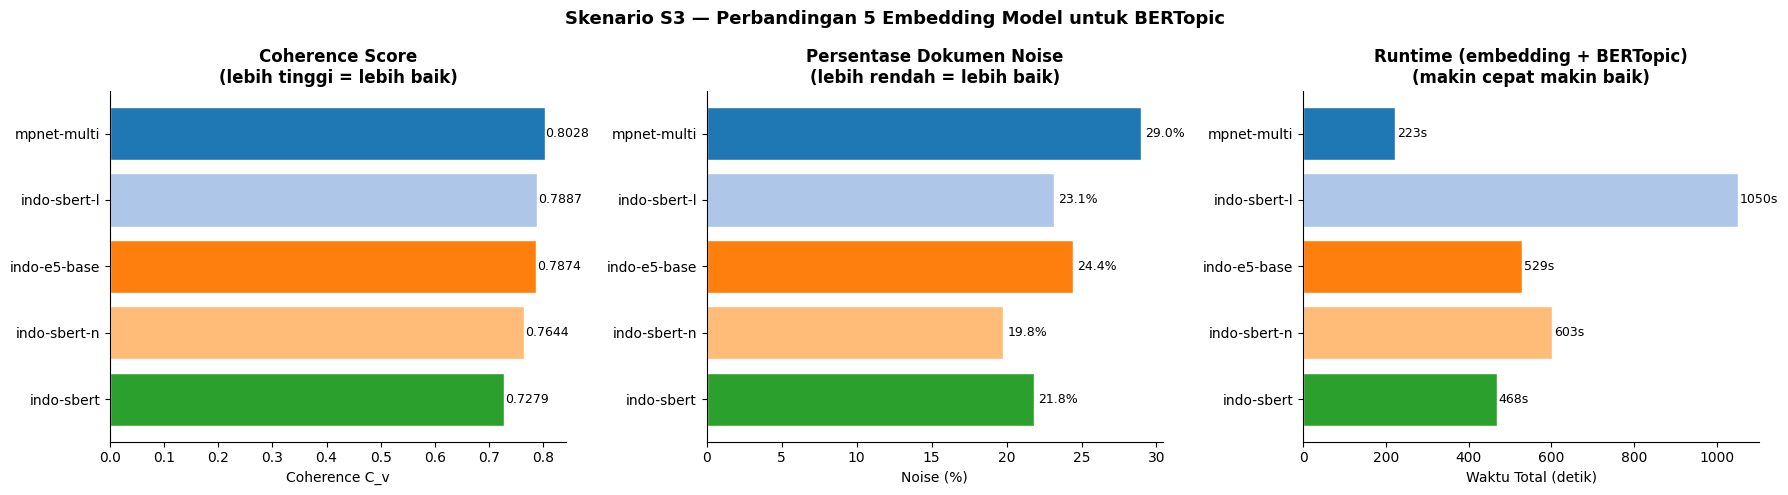

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Skenario S3 — Perbandingan 5 Embedding Model untuk BERTopic',
             fontweight='bold', fontsize=13)

colors = sns.color_palette(PALETTE, len(df_cmp))

# (1) Coherence — metric utama
axes[0].barh(df_cmp['model'], df_cmp['coherence_C_v'], color=colors, edgecolor='white')
axes[0].set_xlabel('Coherence C_v')
axes[0].set_title('Coherence Score\n(lebih tinggi = lebih baik)', fontweight='bold')
for i, v in enumerate(df_cmp['coherence_C_v']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
axes[0].invert_yaxis()
axes[0].spines[['top','right']].set_visible(False)

# (2) Noise %
axes[1].barh(df_cmp['model'], df_cmp['noise_%'], color=colors, edgecolor='white')
axes[1].set_xlabel('Noise (%)')
axes[1].set_title('Persentase Dokumen Noise\n(lebih rendah = lebih baik)', fontweight='bold')
for i, v in enumerate(df_cmp['noise_%']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
axes[1].invert_yaxis()
axes[1].spines[['top','right']].set_visible(False)

# (3) Runtime
axes[2].barh(df_cmp['model'], df_cmp['total_time_s'], color=colors, edgecolor='white')
axes[2].set_xlabel('Waktu Total (detik)')
axes[2].set_title('Runtime (embedding + BERTopic)\n(makin cepat makin baik)', fontweight='bold')
for i, v in enumerate(df_cmp['total_time_s']):
    axes[2].text(v + 5, i, f'{v:.0f}s', va='center', fontsize=9)
axes[2].invert_yaxis()
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_s3_embedding_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Preview top words per topic untuk setiap model
print(f'TOP-7 WORDS per topik (5 topik pertama per model)\n')
for key in df_cmp['model']:
    r = results[key]
    print(f'\n=== [{key.upper()}]  {r["model_name"]}  C_v={r["coherence_cv"]:.4f}  ({r["n_final"]} topik) ===')
    tw = r['topic_words']
    for tid in sorted(tw.keys())[:5]:
        words = ', '.join(tw[tid][:7])
        print(f'  Topik {tid:2d}: {words}')

TOP-7 WORDS per topik (5 topik pertama per model)


=== [MPNET-MULTI]  paraphrase-multilingual-mpnet-base-v2  C_v=0.8028  (11 topik) ===
  Topik  0: jakarta, tahun, pemerintah, masyarakat, anak, kendaraan, nasional
  Topik  1: moto, tim, poin, juara, atlet, marquez, balapan
  Topik  2: ponsel, fitur, pro, pengguna, perangkat, kamera, apple
  Topik  3: iran, trump, kesepakatan, serangan, israel, selat, perang
  Topik  4: run, lari, pelari, event, peserta, olahraga, jogja

=== [INDO-SBERT-L]  denaya/indoSBERT-large  C_v=0.7887  (14 topik) ===
  Topik  0: jakarta, tahun, anak, film, harga, pemerintah, kantor
  Topik  1: moto, balapan, marquez, posisi, pembalap, pebalap, veda
  Topik  2: kurban, haji, sapi, hewan, jamaah, idul, adha
  Topik  3: pengindeksan, copyright, crawling, dilarang, web, izin, otomatis
  Topik  4: korban, pelaku, kebakaran, polisi, tersangka, ditemukan, rumah

=== [INDO-E5-BASE]  intfloat/multilingual-e5-base  C_v=0.7874  (14 topik) ===
  Topik  0: jakarta, tahun, pe

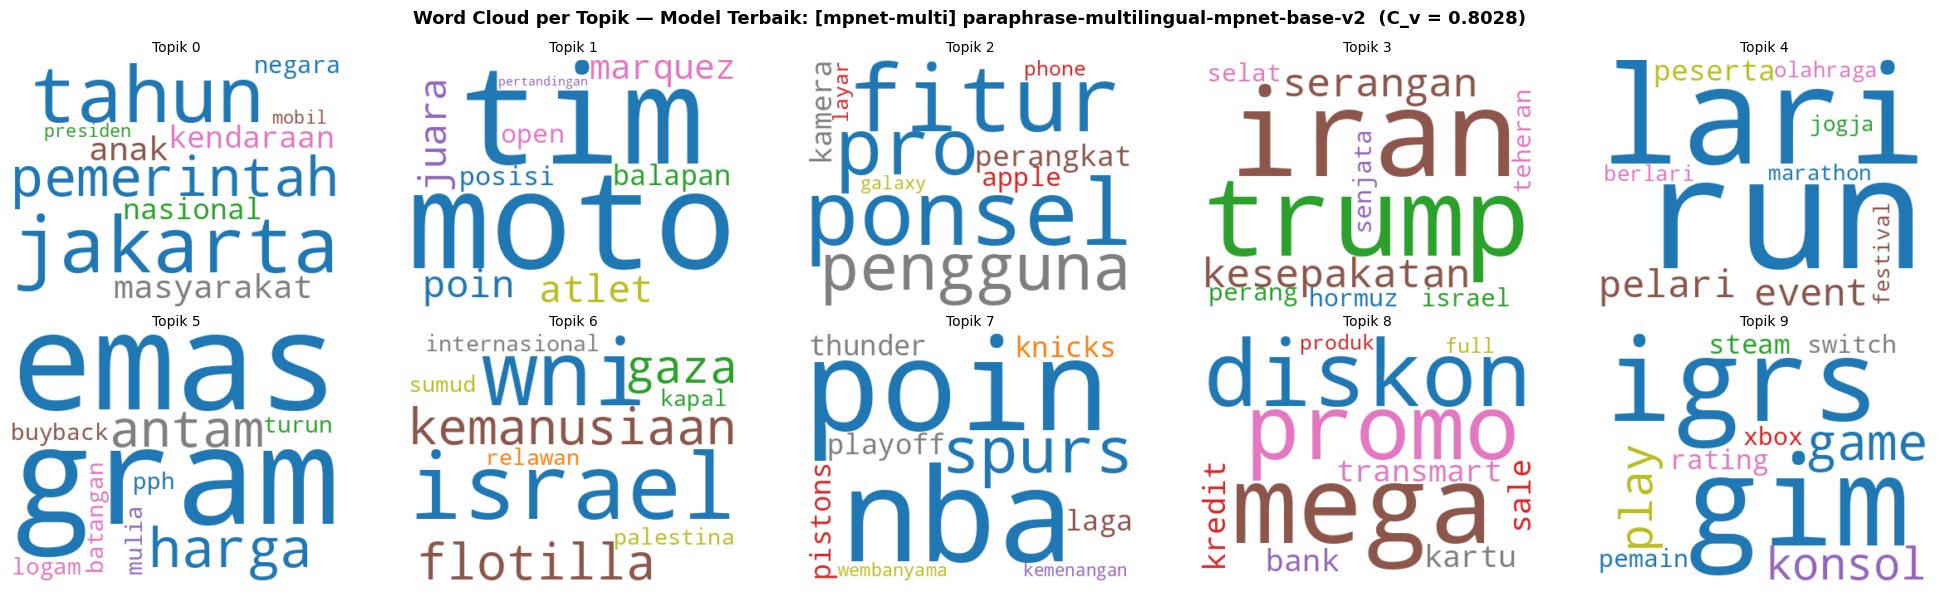

In [10]:
# Word cloud per topik untuk model terbaik (berdasarkan C_v)
best_key  = df_cmp.iloc[0]['model']
best_name = df_cmp.iloc[0]['embedding']
best_cv   = df_cmp.iloc[0]['coherence_C_v']
best_tw   = results[best_key]['topic_words']

n_show = min(len(best_tw), 10)
ncols  = 5
nrows  = -(-n_show // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
axes = axes.flatten() if n_show > 1 else [axes]
fig.suptitle(f'Word Cloud per Topik — Model Terbaik: [{best_key}] {best_name}  '
             f'(C_v = {best_cv:.4f})',
             fontweight='bold', fontsize=13)

for i, tid in enumerate(sorted(best_tw.keys())[:n_show]):
    text = ' '.join(best_tw[tid])
    wc = WordCloud(width=400, height=300, background_color='white',
                   colormap='tab10', random_state=RANDOM_SEED).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topik {tid}', fontsize=10)
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_s3_wordcloud_best.png'), dpi=150, bbox_inches='tight')
plt.show()

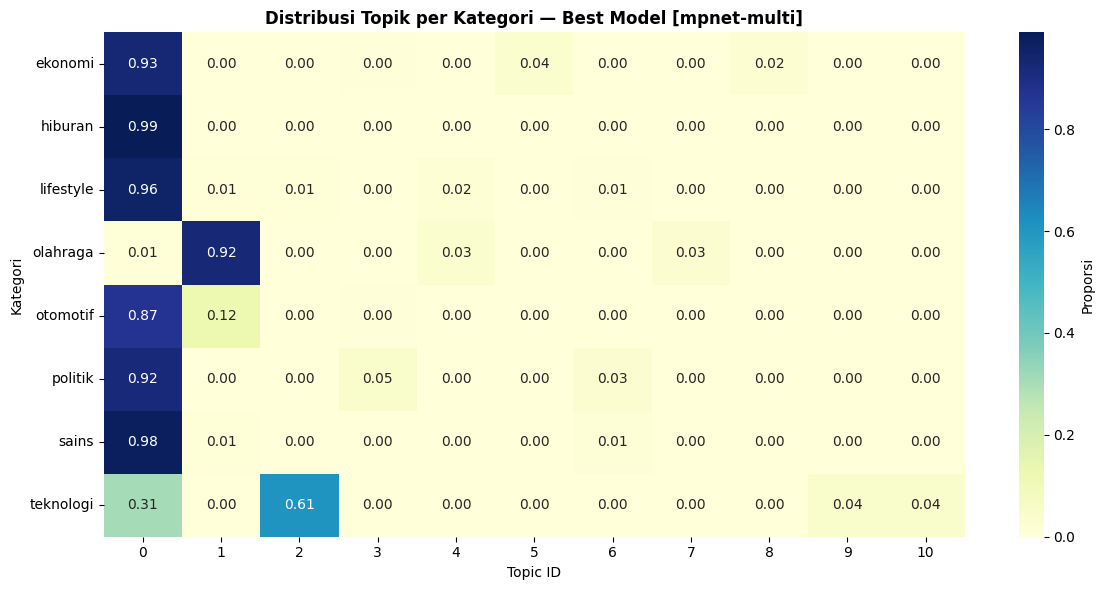

In [11]:
# Heatmap: distribusi topik per kategori untuk model TERBAIK
best_topics = results[best_key]['topics_final']
df_bk = pd.DataFrame({'kategori': df_meta['kategori'], 'topic': best_topics})
df_bk = df_bk[df_bk['topic'] != -1]

ct = pd.crosstab(df_bk['kategori'], df_bk['topic'], normalize='index')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Proporsi'})
ax.set_title(f'Distribusi Topik per Kategori — Best Model [{best_key}]',
             fontweight='bold')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Kategori')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_s3_heatmap_best.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Simpan Hasil

In [12]:
# (1) Tabel komparasi metrik
df_cmp.to_csv(os.path.join(OUTPUT_DIR, 's3_embedding_comparison.csv'), index=False)

# (2) Top words per topik untuk setiap model
topic_words_export = {
    k: {str(t): w for t, w in results[k]['topic_words'].items()}
    for k in results
}
with open(os.path.join(OUTPUT_DIR, 's3_topic_words_per_model.json'), 'w', encoding='utf-8') as f:
    json.dump(topic_words_export, f, ensure_ascii=False, indent=2)

# (3) Topic assignment per dokumen — satu kolom per model
df_assign = pd.DataFrame({k: results[k]['topics_final'] for k in results})
df_assign.to_csv(os.path.join(OUTPUT_DIR, 's3_topic_assignments.csv'), index=False)

print(f'[+] Comparison    : {OUTPUT_DIR}/s3_embedding_comparison.csv')
print(f'[+] Topic words   : {OUTPUT_DIR}/s3_topic_words_per_model.json')
print(f'[+] Assignments   : {OUTPUT_DIR}/s3_topic_assignments.csv')
print(f'[+] Visualisasi   : {OUTPUT_DIR}/fig_s3_*.png')
print(f'\n→ Best model : [{df_cmp.iloc[0]["model"]}] {df_cmp.iloc[0]["embedding"]}')
print(f'→ Coherence  : {df_cmp.iloc[0]["coherence_C_v"]:.4f}')
print(f'→ N topics   : {df_cmp.iloc[0]["n_topics_final"]}')
print(f'→ Noise %    : {df_cmp.iloc[0]["noise_%"]:.2f}%')

[+] Comparison    : /kaggle/working/s3_embedding_comparison.csv
[+] Topic words   : /kaggle/working/s3_topic_words_per_model.json
[+] Assignments   : /kaggle/working/s3_topic_assignments.csv
[+] Visualisasi   : /kaggle/working/fig_s3_*.png

→ Best model : [mpnet-multi] paraphrase-multilingual-mpnet-base-v2
→ Coherence  : 0.8028
→ N topics   : 11
→ Noise %    : 28.97%


## 7. Simpan Model Terbaik (.pkl) — Submission FP

Re-fit ulang BERTopic dengan embedding terbaik (`mpnet-multi`, C_v = 0,8028) lalu simpan sebagai `.pkl`.

> **Catatan:** Di loop eksperimen tadi `topic_model` di-`del` untuk hemat RAM, jadi perlu refit di sini. Embeddings tinggal di-load dari cache (`.npy`), jadi tahap encoding tidak diulang.
>
> Output:
> - `bertopic_best_s3_mpnet.pkl` — model utama untuk dikumpulkan
> - `bertopic_best_s3_meta.json` — metadata pelengkap (config + metrik)

In [ ]:
import pickle

# Pilih model terbaik berdasarkan Coherence C_v dari df_cmp
best_key  = df_cmp.iloc[0]['model']          # 'mpnet-multi'
best_name = df_cmp.iloc[0]['embedding']      # 'paraphrase-multilingual-mpnet-base-v2'
best_cv   = df_cmp.iloc[0]['coherence_C_v']

print(f'Best model : [{best_key}] {best_name}')
print(f'Coherence  : {best_cv:.4f}')
print(f'\nMe-refit BERTopic untuk save...')

# Load embedding dari cache (sudah ada di output dir)
embeddings = np.load(os.path.join(OUTPUT_DIR, f'embeddings_{best_key}.npy'))
print(f'Embeddings : {embeddings.shape}  (loaded from cache)')

# Re-build pipeline persis seperti di eksperimen
encoder = SentenceTransformer(best_name)

umap_model = UMAP(
    n_neighbors=UMAP_NEIGH, n_components=UMAP_DIM,
    min_dist=0.0, metric='cosine',
    random_state=RANDOM_SEED, low_memory=True,
)
hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER, metric='euclidean',
    cluster_selection_method='eom', prediction_data=True,
)

best_model = BERTopic(
    embedding_model=encoder,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics='auto',
    top_n_words=15,
    verbose=True,
    language='multilingual',
    calculate_probabilities=True,   # nyalakan supaya bisa multi-label saat inference
)

best_model.fit_transform(corpus_bert, embeddings)
n_topics = best_model.get_topic_info().shape[0] - 1
print(f'\nTopik final : {n_topics}')

# === SAVE ke .pkl ===
PKL_PATH = os.path.join(OUTPUT_DIR, 'bertopic_best_s3_mpnet.pkl')

best_model.save(
    PKL_PATH,
    serialization='pickle',
    save_embedding_model=True,
    save_ctfidf=True,
)

print(f'\n[+] Model tersimpan : {PKL_PATH}')
print(f'[+] Ukuran file     : {os.path.getsize(PKL_PATH) / 1024 / 1024:.1f} MB')

# Sekalian save metadata supaya kalau dosen mau load, ada konteksnya
model_meta = {
    'model_type':       'BERTopic',
    'embedding_model':  best_name,
    'embedding_dim':    int(embeddings.shape[1]),
    'coherence_cv':     float(best_cv),
    'n_topics':         int(n_topics),
    'umap_config':      {'n_neighbors': UMAP_NEIGH, 'n_components': UMAP_DIM,
                         'min_dist': 0.0, 'metric': 'cosine'},
    'hdbscan_config':   {'min_cluster_size': MIN_CLUSTER, 'metric': 'euclidean',
                         'cluster_selection_method': 'eom'},
    'random_seed':      RANDOM_SEED,
    'corpus_size':      len(corpus_bert),
    'scenario':         'S3 - Embedding Comparison',
}

META_PATH = os.path.join(OUTPUT_DIR, 'bertopic_best_s3_meta.json')
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(model_meta, f, ensure_ascii=False, indent=2)

print(f'[+] Metadata        : {META_PATH}')

In [ ]:
# Verifikasi: load model & test inference dokumen baru
from bertopic import BERTopic

loaded_model = BERTopic.load(PKL_PATH)
print(f'Model berhasil di-load dari {PKL_PATH}')
print(f'Jumlah topik       : {loaded_model.get_topic_info().shape[0] - 1}')

# Test inference dengan kalimat baru
test_docs = [
    "Harga emas Antam hari ini naik signifikan ke level tertinggi",
    "Pemerintah meluncurkan regulasi digital untuk perlindungan anak",
    "Marquez menang balapan MotoGP Italia akhir pekan ini",
    "IHSG ditutup melemah pada perdagangan hari ini",
]

topics_new, probs_new = loaded_model.transform(test_docs)

print('\n=== Test Inference ===')
for doc, t in zip(test_docs, topics_new):
    if t == -1:
        label = '(noise / outlier)'
    else:
        words = loaded_model.get_topic(t)
        label = ', '.join([w for w, _ in words[:5]])
    print(f'\nDocument : "{doc[:65]}..."')
    print(f'Topic    : {t}  →  {label}')

## 8. Catatan & Interpretasi

**Hal yang perlu dianalisis dari hasil:**
1. **Coherence C_v** — metric utama; semakin tinggi semakin koheren topik yang dihasilkan.
2. **Jumlah topik auto (`n_topics_auto`)** — model yang menghasilkan banyak cluster natural cenderung punya representasi yang lebih granular.
3. **Noise %** — dokumen yang tidak masuk ke topik manapun (HDBSCAN label `-1`). Embedding yang lebih baik biasanya menghasilkan noise lebih rendah.
4. **Runtime** — trade-off antara kualitas vs kecepatan. Model 384-dim seperti MiniLM jauh lebih cepat tapi seringkali coherence-nya lebih rendah daripada 768-dim.
5. **Indo-SBERT vs multilingual** — model khusus bahasa Indonesia *seharusnya* lebih unggul untuk korpus berbahasa Indonesia; bandingkan apakah ekspektasi ini terkonfirmasi atau tidak.

**Kesimpulan akhir** dapat ditulis di laporan setelah melihat angka konkret dari `df_cmp` dan visualisasinya.